# 10장 실습 — 특권 교사와 이력 학생

로코모션은 sim2real이 크게 이긴 자리다. 시뮬에서만 학습한 정책이 실제 사족보행 로봇을 산길로 내보내는 데까지 왔다. 조작에서는 아직 그만한 일이 없다.

무엇이 달랐나. 이 장의 답은 세 가지인데, 그중 가장 중요한 하나가 **특권 학습**이다. 시뮬 안에서는 마찰도 질량도 지면의 높낮이도 공짜로 읽을 수 있다. 실기에서는 못 읽는다. 그래서 두 단으로 나눈다 — 먼저 **다 아는 교사**를 학습시키고, 그 다음 **읽을 수 있는 것만 보는 학생**에게 흉내 내게 한다.

이 노트북은 그 절차를 이 책의 밀기 과제에 그대로 옮긴다. 다리 로봇은 CPU에서 몇 분 안에 학습되지 않지만, **기법의 골격과 그것이 무엇을 사는지**는 이 작은 과제에서도 똑같이 잰다.

실행 시간은 CPU에서 6분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 마찰을 에피소드마다 바꾼다

6장에서 랜덤화를 걸었을 때 정책은 손잡이 네 개짜리 규칙이었고, 분포 전체를 하나의 상수 조합으로 감당해야 했다. 그래서 폭을 넓히면 보수적으로 변하거나 아예 못 배웠다.

신경망 정책에는 다른 길이 있다. **지금 어떤 세계에 있는지 알아내서 거기에 맞추는 것**이다. 그러려면 그 값을 관측에 넣어 주거나, 관측에서 유추하게 해야 한다.

여기서는 마찰을 에피소드마다 0.30에서 1.20 사이에서 새로 뽑는다. 밀기 과제에서 마찰은 지배적인 변수다 — 같은 힘으로 밀어도 블록이 두 배 넘게 다른 거리를 간다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MU_LO, MU_HI = .30, 1.20
K = 6                      # 학생이 보는 이력 길이
CACHE = {}


def model_of(mu):
    k = round(mu, 2)
    if k not in CACHE:
        CACHE[k] = mujoco.MjModel.from_xml_string(XML.format(mu=k))
    return CACHE[k]

## 같은 상태, 세 가지 관측

환경은 하나인데 정책에게 보여 주는 것을 셋으로 나눈다.

- **교사** — 기본 관측 여덟 개에 **참 마찰값**을 더해 아홉 개. 시뮬 안에서만 가능한 특권이다
- **눈먼 정책** — 기본 관측 여덟 개뿐. 마찰이 매번 다른데 알 길이 없다
- **학생** — 기본 관측에 **최근 여섯 스텝의 (관측, 행동) 이력**을 붙여 예순여덟 개. 참 마찰은 못 보지만, 같은 명령에 블록이 얼마나 밀렸는지는 이력에 남아 있다

실기에 올릴 수 있는 것은 뒤의 둘뿐이다. 마찰계수를 읽어 주는 센서는 없다.

In [4]:
class Vec:
    def __init__(self, n, seed=0, lat=0, fixed_mu=None):
        self.n, self.lat, self.fixed = n, lat, fixed_mu
        self.rng = np.random.default_rng(seed)
        self.mu = np.zeros(n)
        self.m = [None] * n
        self.d = [None] * n
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.hist = [None] * n
        self.buf = [None] * n
        for i in range(n):
            self.reset(i)
        self.sub = int(round(1 / 20 / self.m[0].opt.timestep))

    def reset(self, i):
        mu = (self.fixed if self.fixed is not None
              else float(self.rng.uniform(MU_LO, MU_HI)))
        self.mu[i] = round(mu, 2)
        m = model_of(self.mu[i])
        self.m[i] = m
        self.d[i] = d = mujoco.MjData(m)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
        self.hist[i] = [np.zeros(10, np.float32) for _ in range(K)]
        self.buf[i] = [np.zeros(2)] * (self.lat + 1)

    def base(self, i):
        d = self.d[i]
        o = np.empty(8, np.float32)
        o[0:2] = self.g[i] - d.qpos[0:2]
        o[2:4] = d.qvel[0:2]
        o[4:6] = d.qpos[0:2] - d.qpos[7:9]
        o[6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def obs(self, kind):
        if kind == "teacher":
            return np.stack([
                np.concatenate([self.base(i), [self.mu[i]]]
                               ).astype(np.float32)
                for i in range(self.n)])
        if kind == "blind":
            return np.stack([self.base(i) for i in range(self.n)])
        return np.stack([
            np.concatenate([self.base(i)] + self.hist[i]
                           ).astype(np.float32)
            for i in range(self.n)])

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        done = np.zeros(self.n, np.float32)
        succ = []
        for i in range(self.n):
            m, d = self.m[i], self.d[i]
            cl = np.clip(a[i], -1, 1)
            self.buf[i].append(cl * AMAX)
            d.ctrl[:] = self.buf[i][-1 - self.lat]
            self.hist[i].append(
                np.concatenate([self.base(i), cl]
                               ).astype(np.float32))
            self.hist[i] = self.hist[i][-K:]
            for _ in range(self.sub):
                mujoco.mj_step(m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                done[i] = 1.
                succ.append(float(db < GOAL_R))
                self.reset(i)
        return r, done, succ


DIN = {"teacher": 9, "blind": 8, "student": 8 + 10 * K}

## 학습기와 증류기

PPO는 8장 것 그대로다. 새로 붙는 것은 `distill` 하나다.

증류는 지도학습이다. 그런데 어떤 상태에서 배울지가 중요하다. **교사가 방문하는 상태에서 배우면 안 된다** — 실기에 올라가는 것은 학생이고, 학생이 실수해서 들어간 상태에서 무엇을 해야 하는지를 배워야 하기 때문이다. 그래서 **학생이 굴리고, 그 상태에서 교사에게 답을 물어본다.** DAgger 계열이 로코모션 증류의 표준이 된 이유다.

In [5]:
class AC(nn.Module):
    def __init__(self, din):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train(kind, budget, seed=0, lr=3e-3, n=16, T=32):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    din = DIN[kind]
    ac = AC(din)
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs(kind)
    steps, won = 0, []
    while steps < budget:
        O = np.empty((T, n, din), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                dist = ac.dist(ot)
                a = dist.sample()
                LP[t] = dist.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], sc = env.step(A[t])
            o = env.obs(kind)
            won += sc
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, din))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                dist = ac.dist(bo[j])
                lp = dist.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * dist.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


def distill(teacher, rounds=120, n=16, T=32, seed=1):
    torch.manual_seed(seed)
    st = AC(DIN["student"])
    opt = torch.optim.Adam(st.parameters(), 1e-3)
    env = Vec(n, seed)
    for _ in range(rounds):
        OS, AT = [], []
        for t in range(T):
            os_ = env.obs("student")
            ot = env.obs("teacher")
            with torch.no_grad():
                a_t = teacher.pi(torch.from_numpy(ot)).numpy()
                ds = st.dist(torch.from_numpy(os_))
                a_s = ds.sample().numpy()
            OS.append(os_)
            AT.append(a_t)
            env.step(a_s)          # 학생이 굴리고 교사에게 물어본다
        bo = torch.from_numpy(np.concatenate(OS))
        ba = torch.from_numpy(np.concatenate(AT))
        for _ in range(16):
            j = torch.randperm(bo.shape[0])[:512]
            loss = ((st.pi(bo[j]) - ba[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return st


def score(ac, kind, n=150, lat=0, fixed_mu=None, seed=999):
    env = Vec(8, seed, lat=lat, fixed_mu=fixed_mu)
    got = []
    while len(got) < n:
        o = torch.from_numpy(env.obs(kind))
        with torch.no_grad():
            u = ac.dist(o).sample().numpy()
        got += env.step(u)[2]
    return float(np.mean(got[:n]))

## 셋을 세운다

교사와 눈먼 정책은 같은 예산으로 PPO를 돌린다. 학생은 학습을 따로 하지 않고 교사를 증류해서 만든다.

In [6]:
t0 = time.time()
tea = train("teacher", 150_000, seed=0)
print(f"교사 학습 끝  ({time.time()-t0:.0f}s)")
bli = train("blind", 150_000, seed=0)
print(f"눈먼 정책 학습 끝  ({time.time()-t0:.0f}s)")
stu = distill(tea)
print(f"학생 증류 끝  ({time.time()-t0:.0f}s)")

def wilson(p, n, z=1.96):
    # 3장에서 쓴 것과 같은 이항비율 신뢰구간
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return c - h, c + h


POL = (("교사 (참 마찰을 본다)", tea, "teacher"),
       ("학생 (이력을 본다)", stu, "student"),
       ("눈먼 정책", bli, "blind"))
N_EVAL = 300
res = {}
print()
print(pad("정책", 22) + pad("관측", 8, True)
      + pad("성공률", 10, True) + pad("95% 구간", 16, True)
      + pad("실기", 8, True))
for name, ac, kind in POL:
    p = score(ac, kind, n=N_EVAL)
    lo, hi = wilson(p, N_EVAL)
    res[name] = (p, lo, hi)
    print(pad(name, 22) + pad(DIN[kind], 8, True)
          + pad(f"{p:.3f}", 10, True)
          + pad(f"[{lo:.2f}, {hi:.2f}]", 16, True)
          + pad("불가" if kind == "teacher" else "가능", 8, True))

교사 학습 끝  (44s)


눈먼 정책 학습 끝  (86s)


학생 증류 끝  (100s)

정책                      관측    성공률        95% 구간    실기


교사 (참 마찰을 본다)        9     0.957    [0.93, 0.97]    불가


학생 (이력을 본다)          68     0.807    [0.76, 0.85]    가능


눈먼 정책                    8     0.743    [0.69, 0.79]    가능


## 이력에 정말 마찰이 실려 있는가

학생이 무엇을 하는지 직접 확인해 본다. 학생의 관측 예순여덟 개에서 **참 마찰값을 선형회귀로** 맞춰 본다. 신경망도 아니고 그냥 최소제곱이다. 비교 대상은 현재 관측 여덟 개만 쓴 경우다.

In [7]:
env = Vec(16, 7)
X, Y = [], []
for t in range(400):
    o = env.obs("student")
    with torch.no_grad():
        a = stu.dist(torch.from_numpy(o)).sample().numpy()
    if t > 20:                       # 이력이 채워진 뒤부터
        X.append(o.copy())
        Y.append(env.mu.copy())
    env.step(a)
X = np.concatenate(X)
Y = np.concatenate(Y)


def r2(cols):
    A = np.hstack([X[:, :cols], np.ones((len(X), 1))])
    w = np.linalg.lstsq(A, Y, rcond=None)[0]
    e = A @ w - Y
    return 1 - (e ** 2).sum() / ((Y - Y.mean()) ** 2).sum()


print(f"표본 {len(Y):,} 개")
print(pad("무엇에서 마찰을 맞히나", 26) + pad("R²", 8, True))
print(pad("현재 관측 8 개만", 26) + pad(f"{r2(8):.3f}", 8, True))
print(pad("현재 관측 + 이력 68 개", 26)
      + pad(f"{r2(68):.3f}", 8, True))

표본 6,064 개
무엇에서 마찰을 맞히나          R²
현재 관측 8 개만             0.061
현재 관측 + 이력 68 개       0.384


## 지연은 어디서 끊는가

이력으로 복원할 수 있는 것과 없는 것이 갈린다. 마찰은 복원됐다. 제어 지연은 어떤가.

학습은 지연 없이 했다. 이제 평가할 때만 지연을 한 스텝씩 넣어 본다.

In [8]:
LATS = (0, 1, 2, 3, 4, 6)
curve = {}
PAIR = (("교사", tea, "teacher"), ("학생", stu, "student"))
for name, ac, kind in PAIR:
    curve[name] = [score(ac, kind, n=80, lat=L) for L in LATS]

print(pad("지연 (스텝)", 14)
      + "".join(pad(L, 8, True) for L in LATS))
for name, v in curve.items():
    print(pad(name, 14)
          + "".join(pad(f"{x:.2f}", 8, True) for x in v))

지연 (스텝)          0       1       2       3       4       6
교사              0.95    0.90    0.54    0.19    0.00    0.00
학생              0.84    0.61    0.35    0.06    0.03    0.03


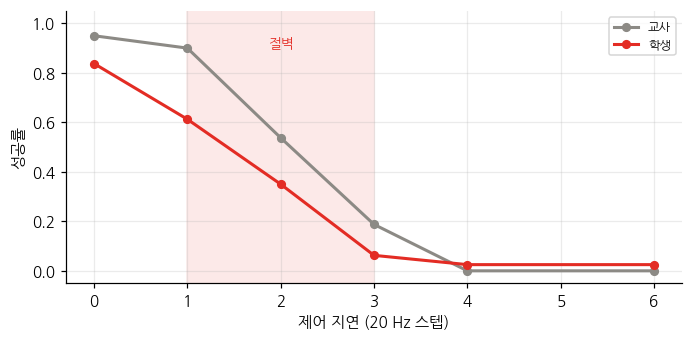

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for (name, v), c in zip(curve.items(), (GREY, RED)):
    ax.plot(LATS, v, "o-", color=c, lw=2, ms=5, label=name)
ax.axvspan(1, 3, color="#FCE9E8", zorder=0)
ax.text(2, .9, "절벽", ha="center", fontsize=9, color=RED)
ax.set_xlabel("제어 지연 (20 Hz 스텝)")
ax.set_ylabel("성공률")
ax.set_ylim(-.05, 1.05)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 정리

**특권 학습은 문제를 두 개로 쪼갠다.** 「어려운 제어를 배우는 일」은 다 아는 교사에게 맡기고, 「읽을 수 있는 것만으로 그 행동을 내는 일」은 학생에게 맡긴다. 하나의 정책이 둘을 동시에 하는 것보다 쉽다.

**그런데 이 과제에서는 값을 크게 하지 못했다.** 학생이 눈먼 정책보다 나은 쪽으로 보이지만 신뢰구간이 겹친다. 상태를 다 보고 매 스텝 고칠 수 있는 과제에서는 피드백이 숨은 파라미터를 흡수하기 때문이다. **특권 학습이 값을 하는 곳은 고칠 시간이 없는 과제다** — 접촉이 순간적이고 주기가 빠르고 넘어지면 끝인 로코모션이 바로 그런 자리다.

**교사는 산출물이 아니라 발판이다.** 참 마찰을 보는 정책은 실기에 올라갈 수 없다. 교사의 성적은 「학생이 잘하면 어디까지 갈 수 있는가」의 상한으로만 읽는다.

**증류는 학생이 굴리는 상태에서 해야 한다.** 실기에서 마주칠 상태는 학생이 만든 상태이지 교사가 만든 상태가 아니다.

**숨은 파라미터는 관측에 없어도 이력에는 있다.** 현재 관측만으로는 마찰을 전혀 못 맞히는데, 여섯 스텝 이력을 넣으면 선형회귀만으로도 상당 부분이 맞는다. 로코모션 정책이 고유수용 이력만으로 지면을 읽는 것이 이 구조다.

**지연에는 절벽이 있고, 이력을 쓰는 정책이 먼저 떨어진다.** 재야 할 것은 지금의 성적이 아니라 끊기는 자리다.

그런데 이 모든 것이 성립한 전제가 하나 있다. **블록이 어디 있는지는 처음부터 알려 줬다.** 마찰은 이력에서 복원됐지만, 물체의 위치는 이력으로 복원되는 물건이 아니다. 다음 장이 그 이야기다.